In [56]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def load_rtl_layer(path, nfrac):
    raw = np.loadtxt(path, delimiter=',')
    flat = raw.flatten()
    return flat / (2 ** nfrac)

def load_ref_layer(path):
    return np.loadtxt(path, delimiter=',')

def rtl_path(test_num, suffix):
    return f"/home/aya/HLS4ML_VS_MANUAL/src/hdl/RHEED_Gaussian/python/populated_traces/rtl_{test_num}_{suffix}.csv"

def hls_path(test_num, suffix):
    return f"/home/aya/HLS4ML_VS_MANUAL/src/hdl/RHEED_Gaussian/python/traces/hls4ml_{test_num}_{suffix}.csv"

def keras_path(test_num, suffix):
    return f"/home/aya/HLS4ML_VS_MANUAL/src/hdl/RHEED_Gaussian/python/traces/keras_{test_num}_{suffix}.csv"

def extract_top_level_util(file, top_names=("myproject", "rheedGaussianWrapper")):
    with open(file) as f:
        text = f.read()
    pattern = (
        r"\|\s*(" + "|".join(top_names) + r")\s*\|\s*\(top\)\s*\|\s*(\d+)\s*\|\s*(\d+)\s*\|\s*(\d+)\s*\|"
        r"\s*(\d+)\s*\|\s*(\d+)\s*\|\s*(\d+)\s*\|\s*(\d+)\s*\|\s*(\d+)\s*\|\s*(\d+)\s*\|"
    )
    m = re.search(pattern, text)
    if m:
        return {
            "Total LUTs": int(m.group(2)), "FFs": int(m.group(6)),
            "RAMB36": int(m.group(7)), "RAMB18": int(m.group(8)), "DSP48": int(m.group(10)),
        }
    return None

def extract_util_percent(file, resources=("CLB LUTs", "CLB Registers", "Block RAM Tile", "DSPs")):
    with open(file) as f:
        text = f.read()
    out = {}
    for r in resources:
        m = re.search(re.escape(r) + r"\s*\|\s*(\d+)\s*\|\s*\d*\s*\|\s*\d*\s*\|\s*(\d+)\s*\|\s*([\d.]+)", text)
        if m:
            out[r] = {"used": int(m.group(1)), "available": int(m.group(2)), "percent": float(m.group(3))}
    return out


def extract_timing_summary(file):
    with open(file) as f:
        text = f.read()
    m = re.search(
        r"WNS\(ns\)\s+TNS\(ns\).*?\n\s*-+\s+-+.*?\n\s*(-?\d+\.\d+)\s+(-?\d+\.\d+)",
        text, re.DOTALL
    )
    if m:
        return {"WNS": float(m.group(1)), "TNS": float(m.group(2))}
    return None

In [57]:
# Handmade RTL vs HLS4ML Summary Results
# Comparison of resource utilization, timing, latency, and accuracy (vs. Keras ground truth) at bitwidth = 8
# Both designs synthesized at a common 10ns (100MHz) clock target.

In [58]:
rows = []
for idx in range(50):
    label = f"populated{idx}"
    hls = load_ref_layer(hls_path(label, "q_dense_2"))
    keras = load_ref_layer(keras_path(label, "q_dense_2"))
    rows.append({
        "image": idx,
        "keras_vs_hls": np.abs(keras - hls).mean(),
    })

rtl_stream_50 = np.loadtxt("/home/aya/HLS4ML_VS_MANUAL/src/hdl/RHEED_Gaussian/python/streaming_traces_50/rtl_streaming_final.csv", delimiter=',')
Nfrac_final = 5
for row in rtl_stream_50:
    idx = int(row[0])
    rtl_decimal = row[1:] / (2**Nfrac_final)
    keras = load_ref_layer(keras_path(f"populated{idx}", "q_dense_2"))
    rows[idx]["keras_vs_rtl"] = np.abs(keras - rtl_decimal).mean()

df = pd.DataFrame(rows)
print(df.to_string(index=False))
print(f"\nMean RTL error vs Keras:    {df['keras_vs_rtl'].mean():.4f}")
print(f"Mean HLS4ML error vs Keras: {df['keras_vs_hls'].mean():.4f}")
print(f"RTL closer to Keras in {(df['keras_vs_rtl'] < df['keras_vs_hls']).sum()} / 50 tests")

 image  keras_vs_hls  keras_vs_rtl
     0      0.108105      0.057324
     1      0.101660      0.042480
     2      0.165332      0.085059
     3      0.127832      0.077832
     4      0.177734      0.145117
     5      0.062109      0.066797
     6      0.100977      0.040039
     7      0.055762      0.015918
     8      0.045703      0.032031
     9      0.050000      0.071094
    10      0.062109      0.063672
    11      0.103223      0.060449
    12      0.147266      0.080469
    13      0.092480      0.109082
    14      0.083984      0.050977
    15      0.050781      0.082031
    16      0.079883      0.127148
    17      0.134668      0.122168
    18      0.117285      0.070020
    19      0.154004      0.117480
    20      0.075488      0.033691
    21      0.068457      0.071777
    22      0.159863      0.147363
    23      0.148828      0.124414
    24      0.160742      0.140430
    25      0.115234      0.063867
    26      0.084961      0.055273
    27      0.185352

In [59]:
handmade_util = extract_top_level_util("/home/aya/HLS4ML_VS_MANUAL/src/hdl/RHEED_Gaussian/reports/handmade_reports/gaussian_handmade_util.rpt")
hls_util = extract_top_level_util("/home/aya/HLS4ML_VS_MANUAL/src/hdl/RHEED_Gaussian/reports/hls4ml_reports_new/gaussian_hls4ml_util.rpt")

handmade_timing = extract_timing_summary("/home/aya/HLS4ML_VS_MANUAL/src/hdl/RHEED_Gaussian/reports/handmade_reports/gaussian_handmade_timing.rpt")
hls_timing = extract_timing_summary("/home/aya/HLS4ML_VS_MANUAL/src/hdl/RHEED_Gaussian/reports/hls4ml_reports_new/gaussian_hls4ml_timing.rpt")

print("Handmade:", handmade_util, handmade_timing)
print("HLS4ML:  ", hls_util, hls_timing)



Handmade: {'Total LUTs': 20076, 'FFs': 6657, 'RAMB36': 0, 'RAMB18': 0, 'DSP48': 0} {'WNS': 1.174, 'TNS': 0.0}
HLS4ML:   {'Total LUTs': 24618, 'FFs': 15650, 'RAMB36': 18, 'RAMB18': 56, 'DSP48': 0} {'WNS': 2.669, 'TNS': 0.0}


In [60]:
# KU035 device capacity 
# Xilinx datasheet specs: https://docs.amd.com/api/khub/documents/dGU6Y~1b8XPqDFk5ulti6g/content
# Table 7
DEVICE_CAPACITY = {
    "Total LUTs": 203128,
    "FFs": 406256,
    "RAMB36": 540,
    "DSP48": 1700,
}

def compute_percent(util_dict, capacity=DEVICE_CAPACITY):
    return {k: (util_dict[k] / capacity[k] * 100) for k in capacity if k in util_dict}

handmade_pct = compute_percent(handmade_util)
hls_pct = compute_percent(hls_util)
print("Handmade %:", handmade_pct)
print("HLS4ML %:  ", hls_pct)

Handmade %: {'Total LUTs': 9.88342326021031, 'FFs': 1.6386219526603913, 'RAMB36': 0.0, 'DSP48': 0.0}
HLS4ML %:   {'Total LUTs': 12.119451774250718, 'FFs': 3.852250797526683, 'RAMB36': 3.3333333333333335, 'DSP48': 0.0}


In [61]:
summary = pd.DataFrame([
    {
        "Design": "Handmade RTL", "Bits": 8,
        **handmade_util, "WNS @10ns (ns)": handmade_timing["WNS"],
        "Latency (cycles)": 19225, "Latency @10ns (µs)": 19225*10/1000,
        "Mean Abs Error vs Keras": df["keras_vs_rtl"].mean(),
    },
    {
        "Design": "HLS4ML", "Bits": 8,
        **hls_util, "WNS @10ns (ns)": hls_timing["WNS"],
        "Latency (cycles)": "34571-34577 (HLS est.)", "Latency @5ns target (µs)": (34571*5)/1000,
        "Mean Abs Error vs Keras": df["keras_vs_hls"].mean(),
    },
])
summary

,Design,Bits,Total LUTs,FFs,RAMB36,RAMB18,DSP48,WNS @10ns (ns),Latency (cycles),Latency @10ns (µs),Mean Abs Error vs Keras,Latency @5ns target (µs)
0,Handmade RTL,8,20076,6657,0,0,0,1.174,19225,192.25,0.082939,NaN
1,HLS4ML,8,24618,15650,18,56,0,2.669,34571-34577 (HLS est.),NaN,0.104861,172.855


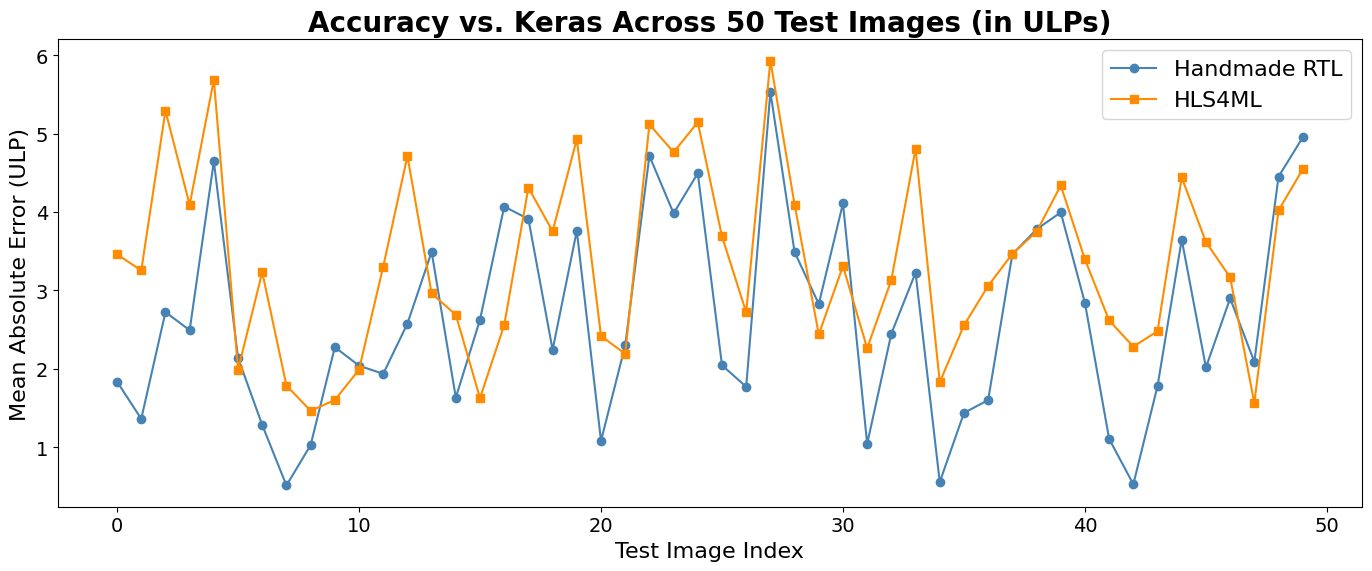

Mean RTL error: 2.65 ULP
Mean HLS4ML error: 3.36 ULP


In [64]:
Nfrac_final = 5  # dense2 precision

df["rtl_ulp"] = df["keras_vs_rtl"] * (2 ** Nfrac_final)
df["hls_ulp"] = df["keras_vs_hls"] * (2 ** Nfrac_final)

plt.figure(figsize=(14, 6))
plt.plot(df["image"], df["rtl_ulp"], marker='o', label="Handmade RTL", color="steelblue")
plt.plot(df["image"], df["hls_ulp"], marker='s', label="HLS4ML", color="darkorange")
plt.xlabel("Test Image Index", fontsize=16)
plt.ylabel("Mean Absolute Error (ULP)", fontsize=16)
plt.title("Accuracy vs. Keras Across 50 Test Images (in ULPs)", fontsize=20, fontweight='bold')
plt.legend(fontsize=16)
plt.tick_params(labelsize=14)
plt.tight_layout()
plt.show()

print(f"Mean RTL error: {df['rtl_ulp'].mean():.2f} ULP")
print(f"Mean HLS4ML error: {df['hls_ulp'].mean():.2f} ULP")

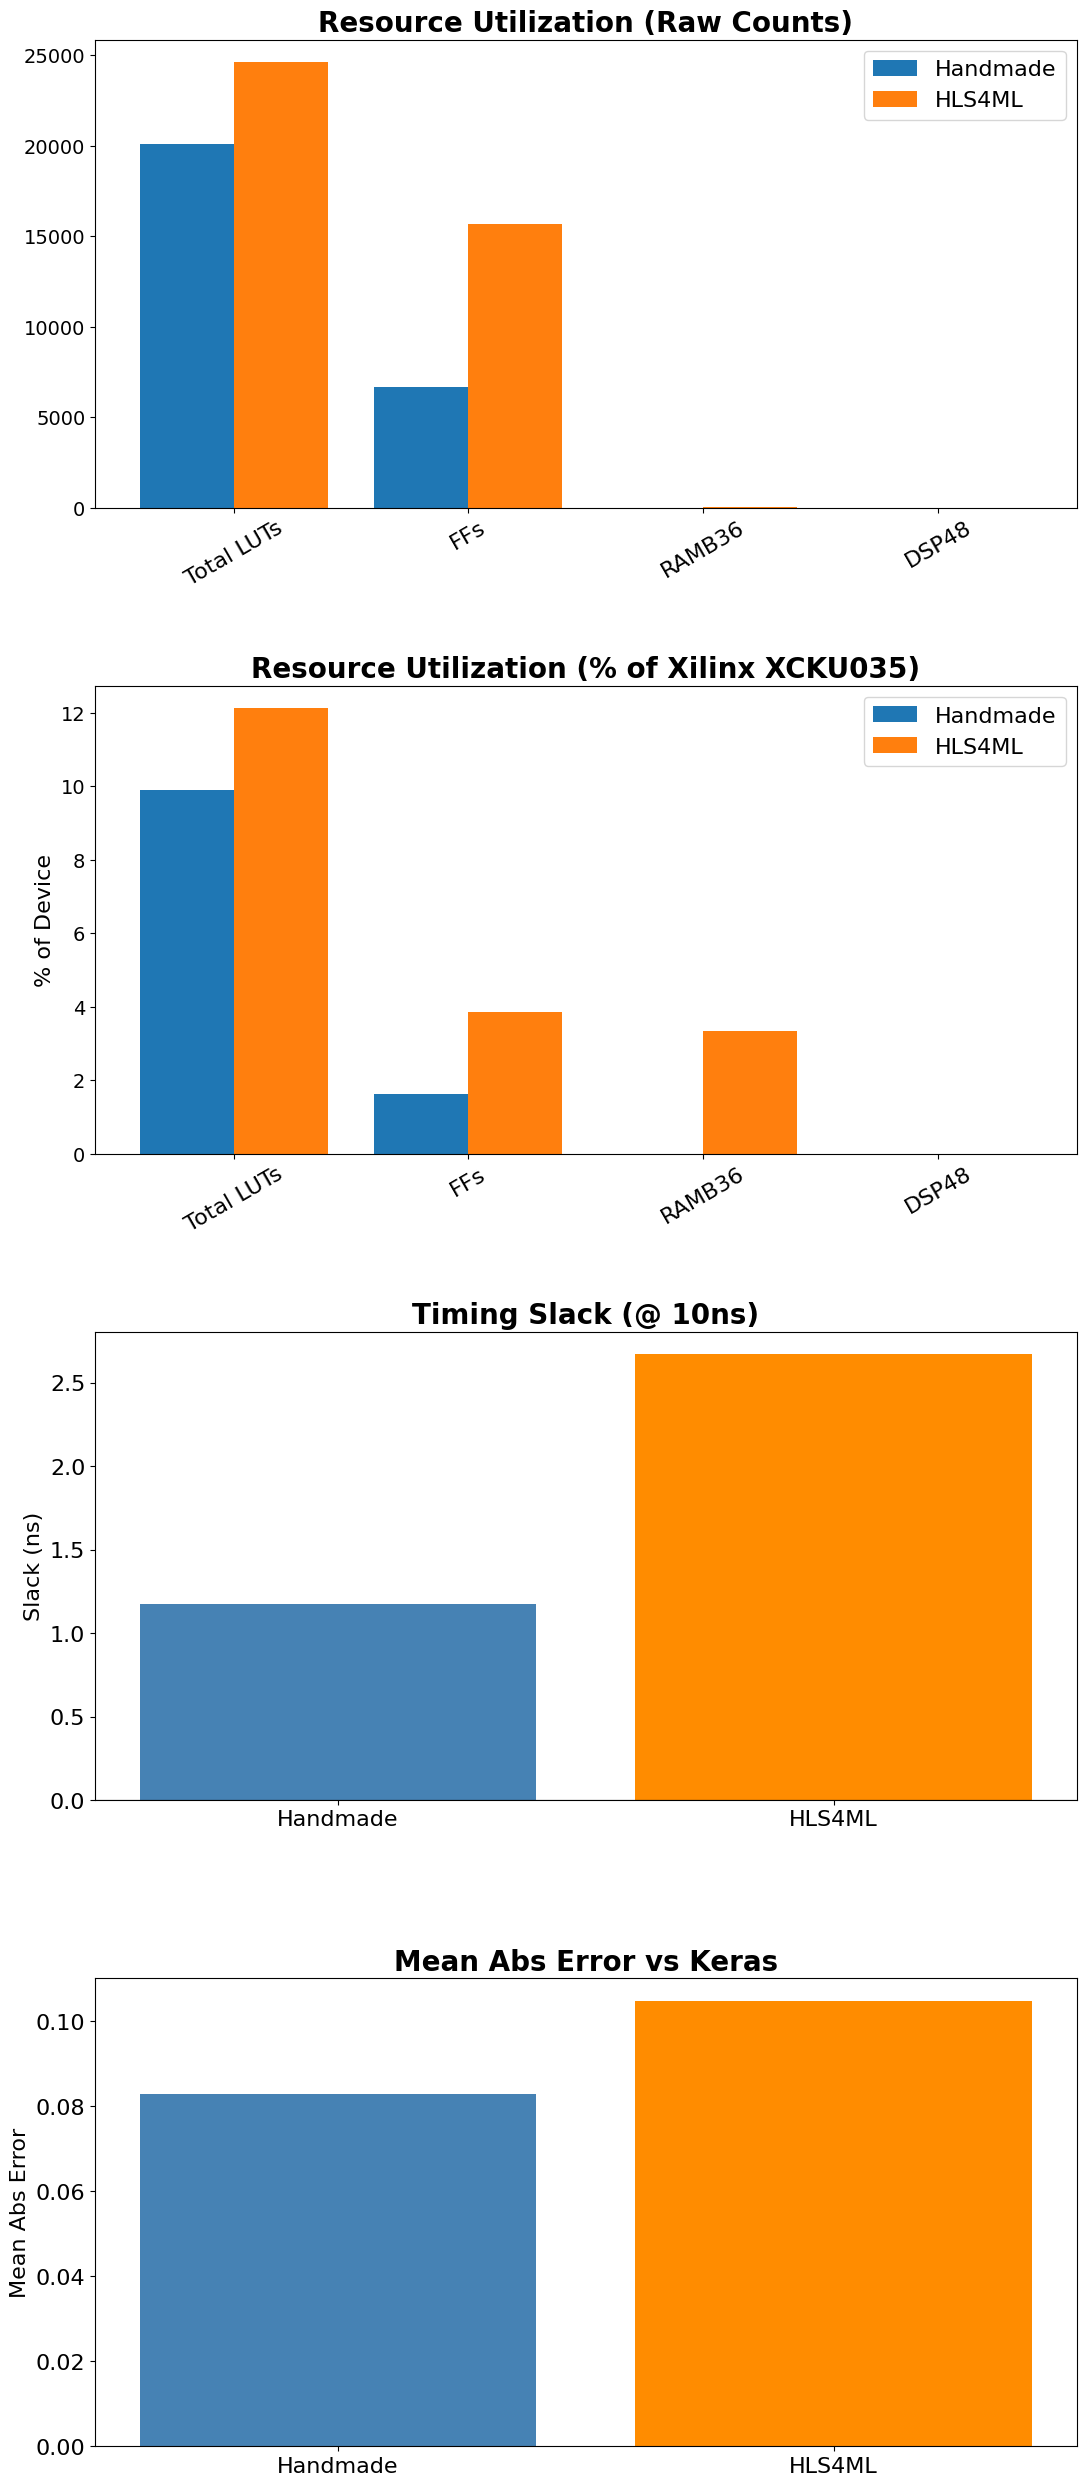

In [63]:
plt.rcParams.update({'font.size': 16})

fig, axes = plt.subplots(4, 1, figsize=(12, 26))

metrics = ["Total LUTs", "FFs", "RAMB36", "DSP48"]
x = np.arange(len(metrics))

# panel 1: raw resource counts
axes[0].bar(x-0.2, [handmade_util[m] for m in metrics], 0.4, label="Handmade")
axes[0].bar(x+0.2, [hls_util[m] for m in metrics], 0.4, label="HLS4ML")
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics, rotation=30, fontsize=16)
axes[0].set_title("Resource Utilization (Raw Counts)", fontsize=20, fontweight='bold')
axes[0].tick_params(axis='y', labelsize=14)
axes[0].legend(fontsize=16)

# panel 2: percent utilization of device (XCKU035 capacity)
axes[1].bar(x-0.2, [handmade_pct[m] for m in metrics], 0.4, label="Handmade")
axes[1].bar(x+0.2, [hls_pct[m] for m in metrics], 0.4, label="HLS4ML")
axes[1].set_xticks(x)
axes[1].set_xticklabels(metrics, rotation=30, fontsize=16)
axes[1].set_title("Resource Utilization (% of Xilinx XCKU035)", fontsize=20, fontweight='bold')
axes[1].set_ylabel("% of Device", fontsize=16)
axes[1].tick_params(axis='y', labelsize=14)
axes[1].legend(fontsize=16)

# panel 3: timing
axes[2].bar(["Handmade","HLS4ML"], [handmade_timing["WNS"], hls_timing["WNS"]], color=["steelblue","darkorange"])
axes[2].axhline(0, color="black", lw=0.8)
axes[2].set_title("Timing Slack (@ 10ns)", fontsize=20, fontweight='bold')
axes[2].set_ylabel("Slack (ns)", fontsize=16)
axes[2].tick_params(axis='both', labelsize=16)

# panel 4: accuracy
axes[3].bar(["Handmade","HLS4ML"], [df["keras_vs_rtl"].mean(), df["keras_vs_hls"].mean()], color=["steelblue","darkorange"])
axes[3].set_title("Mean Abs Error vs Keras", fontsize=20, fontweight='bold')
axes[3].set_ylabel("Mean Abs Error", fontsize=16)
axes[3].tick_params(axis='both', labelsize=16)

plt.tight_layout(pad=3.0)
plt.show()

In [70]:
def parse_hier_report(path):
    with open(path) as f:
        lines = f.readlines()
    header_idx = next(i for i, l in enumerate(lines) if 'Instance' in l and 'Module' in l)
    rows = []
    for line in lines[header_idx + 2:]:
        line = line.rstrip('\n')
        if not line.strip().startswith('|'):
            break
        parts = [p.strip() for p in line.strip().strip('|').split('|')]
        if len(parts) < 11:
            continue
        try:
            rows.append({
                'instance': parts[0],
                'total_luts': int(parts[2]),
                'ffs': int(parts[6]),
                'bram': int(parts[7]) + int(parts[8]),
                'dsp48': int(parts[10]),
            })
        except ValueError:
            continue
    return rows

# handmade per-layer
handmade_rows = parse_hier_report(
    "/home/aya/HLS4ML_VS_MANUAL/src/hdl/RHEED_Gaussian/reports/handmade_reports/gaussian_handmade_util.rpt"
)
handmade_groups = {
    'conv0': ['conv0'], 'pool0': ['pool0Stage1[', 'pool0Stage2['],
    'conv1': ['conv1'], 'pool1': ['pool1['],
    'conv2': ['conv2'], 'pool2': ['pool2['],
    'dense0': ['dense0'], 'relu0': ['relu0'],
    'dense1': ['dense1'], 'relu1': ['relu1'],
    'dense2': ['dense2'],
}
def aggregate(rows, groups):
    out = {}
    for name, prefixes in groups.items():
        matched = [r for r in rows if any(r['instance'].startswith(p) for p in prefixes)]
        out[name] = {
            'total_luts': sum(r['total_luts'] for r in matched),
            'ffs': sum(r['ffs'] for r in matched),
            'bram': sum(r['bram'] for r in matched),
            'dsp48': sum(r['dsp48'] for r in matched),
        }
    return out
handmade_layer_util = aggregate(handmade_rows, handmade_groups)

# hls4ml per-layer
hls4ml_rows = parse_hier_report(
    "/home/aya/HLS4ML_VS_MANUAL/src/hdl/RHEED_Gaussian/reports/hls4ml_reports_new/gaussian_hls4ml_util.rpt"
)
config_to_name = {
    2: 'conv0', 3: 'linear0', 4: 'relu0', 5: 'pool0',
    6: 'conv1', 7: 'linear1', 8: 'relu1', 9: 'pool1',
    10: 'conv2', 11: 'linear2', 12: 'relu2', 13: 'pool2',
    15: 'dense0', 16: 'linear3', 17: 'relu3',
    18: 'dense1', 19: 'linear4', 20: 'relu4',
    21: 'dense2', 22: 'linear5',
}
def classify(instance):
    m = re.search(r'config(\d+)(?:[^0-9]|$)', instance)
    if m:
        return config_to_name.get(int(m.group(1)))
    m = re.search(r'^layer(\d+)_out', instance)
    if m:
        return config_to_name.get(int(m.group(1)))
    return None

hls4ml_layer_util = {name: {'total_luts': 0, 'ffs': 0, 'bram': 0, 'dsp48': 0} for name in set(config_to_name.values())}
for r in hls4ml_rows:
    if r['instance'] in ('myproject', '(myproject)'):
        continue
    group = classify(r['instance'])
    if group is None:
        continue
    hls4ml_layer_util[group]['total_luts'] += r['total_luts']
    hls4ml_layer_util[group]['ffs'] += r['ffs']
    hls4ml_layer_util[group]['bram'] += r['bram']
    hls4ml_layer_util[group]['dsp48'] += r['dsp48']
order = ['conv0','linear0','relu0','pool0','conv1','linear1','relu1','pool1',
         'conv2','linear2','relu2','pool2','dense0','linear3','relu3',
         'dense1','linear4','relu4','dense2','linear5']
hls4ml_layer_util = {k: hls4ml_layer_util[k] for k in order}

# fold both to shared 9-stage grouping for comparison charts
shared_stages = ['conv0', 'pool0', 'conv1', 'pool1', 'conv2', 'pool2', 'dense0', 'dense1', 'dense2']
hls4ml_fold_map = {
    'conv0': ['conv0', 'linear0', 'relu0'], 'pool0': ['pool0'],
    'conv1': ['conv1', 'linear1', 'relu1'], 'pool1': ['pool1'],
    'conv2': ['conv2', 'linear2', 'relu2'], 'pool2': ['pool2'],
    'dense0': ['dense0', 'linear3', 'relu3'],
    'dense1': ['dense1', 'linear4', 'relu4'],
    'dense2': ['dense2', 'linear5'],
}
handmade_fold_map = {
    'conv0': ['conv0'], 'pool0': ['pool0'],
    'conv1': ['conv1'], 'pool1': ['pool1'],
    'conv2': ['conv2'], 'pool2': ['pool2'],
    'dense0': ['dense0', 'relu0'], 'dense1': ['dense1', 'relu1'], 'dense2': ['dense2'],
}
def fold(data, fold_map):
    return {stage: {m: sum(data[p][m] for p in parts) for m in ['total_luts','ffs','bram','dsp48']}
            for stage, parts in fold_map.items()}
handmade_shared = fold(handmade_layer_util, handmade_fold_map)
hls4ml_shared = fold(hls4ml_layer_util, hls4ml_fold_map)

def plot_comparison(handmade, hls4ml, metric, ylabel, title):
    stages = shared_stages
    x = np.arange(len(stages))
    width = 0.35
    plt.figure(figsize=(12, 6))
    plt.bar(x - width/2, [handmade[s][metric] for s in stages], width, label='Handmade')
    plt.bar(x + width/2, [hls4ml[s][metric] for s in stages], width, label='HLS4ML')
    plt.xticks(x, stages, rotation=45, ha='right', fontsize=14)
    plt.ylabel(ylabel, fontsize=16); plt.xlabel('Layer', fontsize=16)
    plt.title(title, fontsize=20, fontweight='bold'); plt.legend(fontsize=14)
    plt.tight_layout(); plt.show()

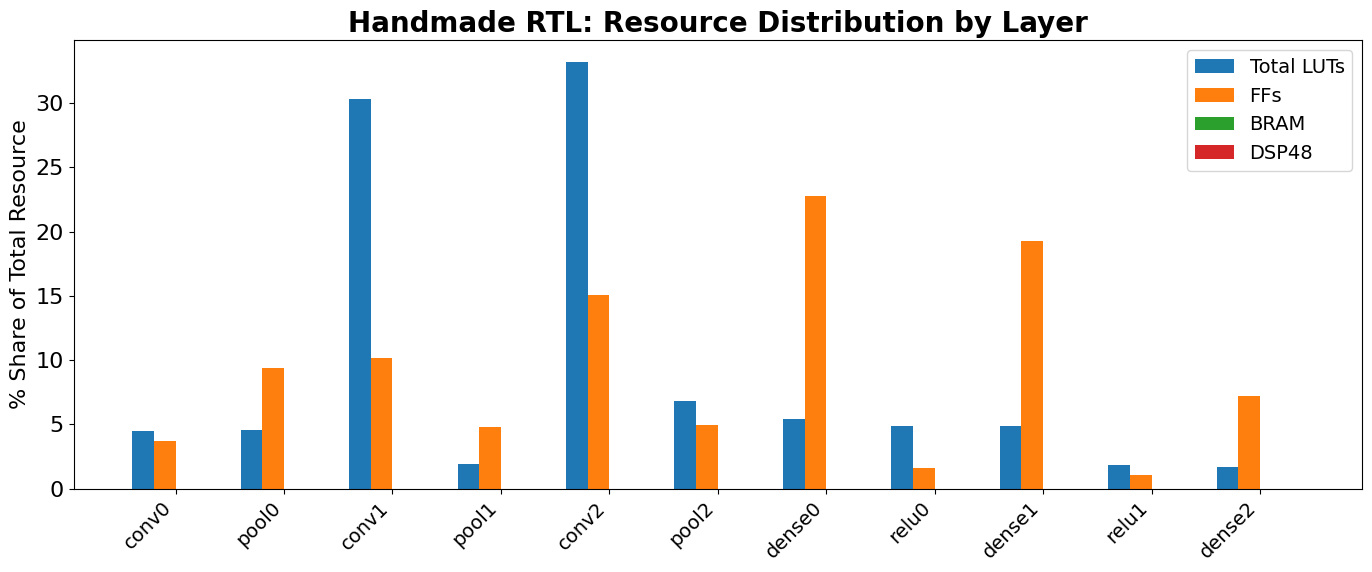

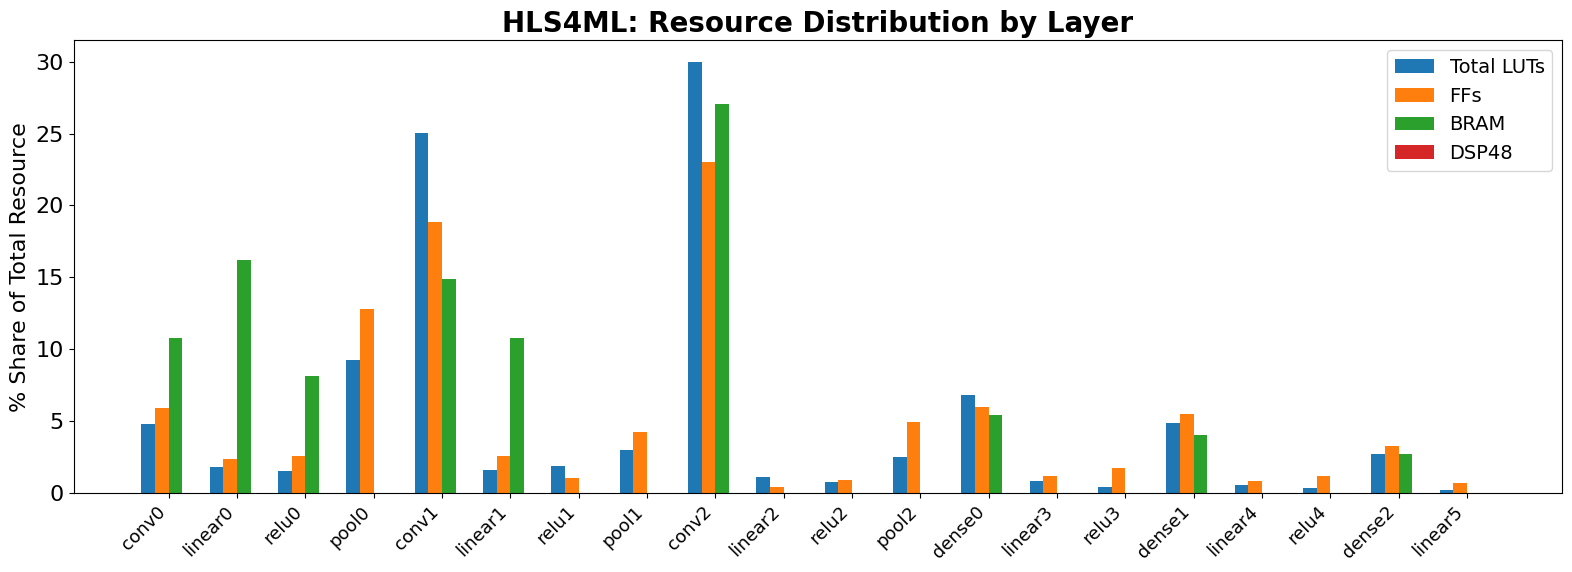

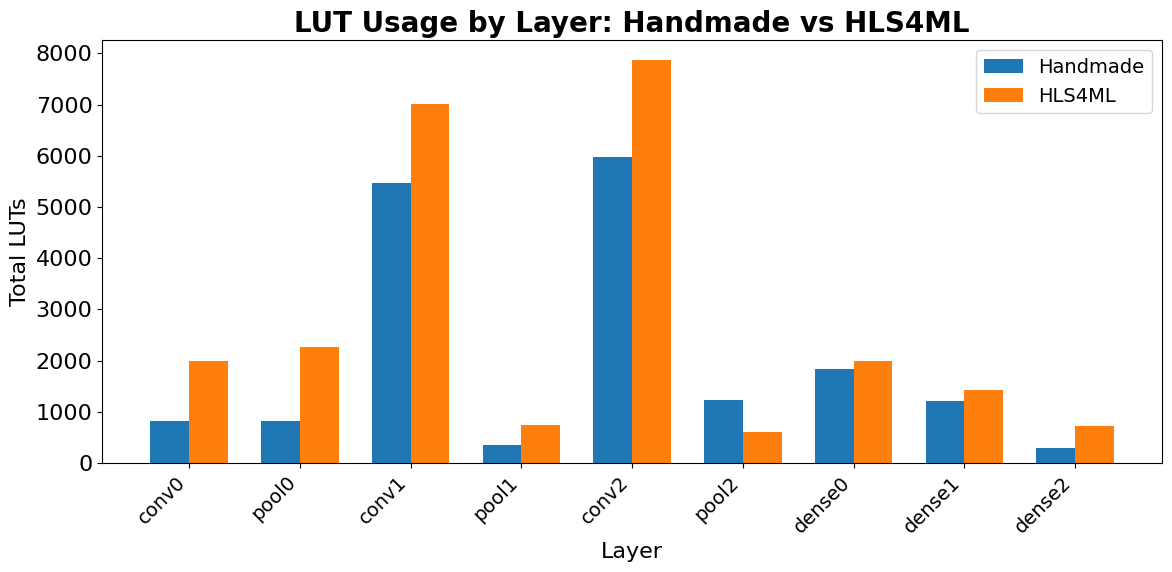

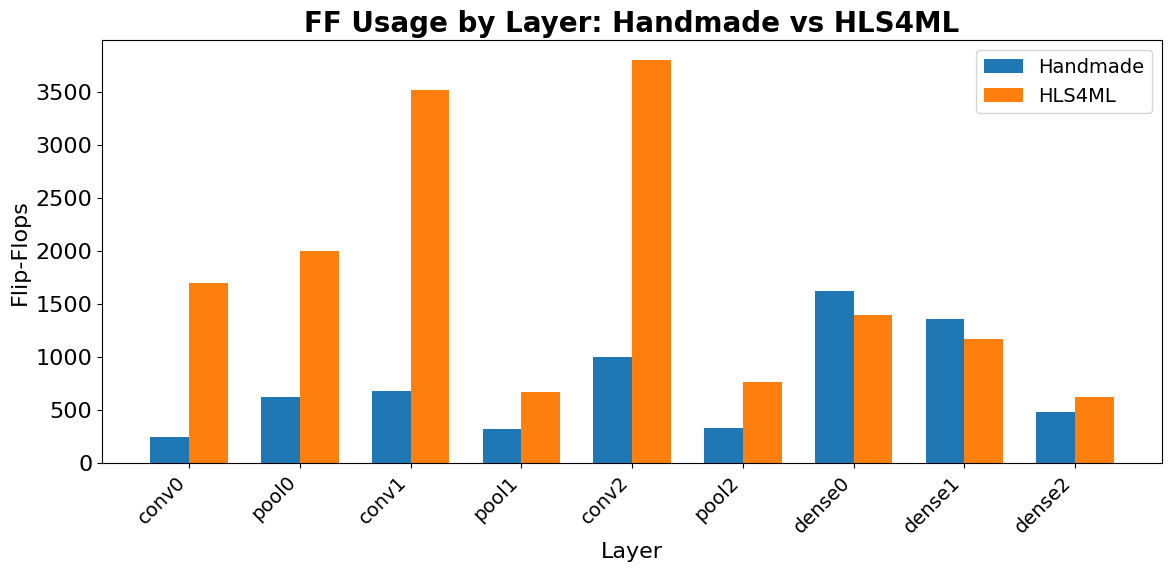

In [71]:


# 1. Handmade RTL per-layer resource distribution
layers = list(handmade_layer_util.keys())
metrics = ['total_luts', 'ffs', 'bram', 'dsp48']
labels = ['Total LUTs', 'FFs', 'BRAM', 'DSP48']
totals = {m: sum(handmade_layer_util[l][m] for l in layers) for m in metrics}
x = np.arange(len(layers))
width = 0.8 / len(metrics)
plt.figure(figsize=(14, 6))
for i, (m, lab) in enumerate(zip(metrics, labels)):
    vals = [100 * handmade_layer_util[l][m] / totals[m] if totals[m] > 0 else 0 for l in layers]
    plt.bar(x + i*width, vals, width=width, label=lab)
plt.xticks(x + width*(len(metrics)-1)/2, layers, rotation=45, ha='right', fontsize=14)
plt.ylabel('% Share of Total Resource', fontsize=16)
plt.title('Handmade RTL: Resource Distribution by Layer', fontsize=20, fontweight='bold')
plt.legend(fontsize=14)
plt.tight_layout()
plt.show()

# 2. HLS4ML per-layer resource distribution
layers = list(hls4ml_layer_util.keys())
totals = {m: sum(hls4ml_layer_util[l][m] for l in layers) for m in metrics}
x = np.arange(len(layers))
plt.figure(figsize=(16, 6))
for i, (m, lab) in enumerate(zip(metrics, labels)):
    vals = [100 * hls4ml_layer_util[l][m] / totals[m] if totals[m] > 0 else 0 for l in layers]
    plt.bar(x + i*width, vals, width=width, label=lab)
plt.xticks(x + width*(len(metrics)-1)/2, layers, rotation=45, ha='right', fontsize=13)
plt.ylabel('% Share of Total Resource', fontsize=16)
plt.title('HLS4ML: Resource Distribution by Layer', fontsize=20, fontweight='bold')
plt.legend(fontsize=14)
plt.tight_layout()
plt.show()

# 3. LUT comparison, handmade vs hls4ml, shared layer stages
plot_comparison(handmade_shared, hls4ml_shared, 'total_luts', 'Total LUTs', 'LUT Usage by Layer: Handmade vs HLS4ML')

# 4. FF comparison, handmade vs hls4ml, shared layer stages
plot_comparison(handmade_shared, hls4ml_shared, 'ffs', 'Flip-Flops', 'FF Usage by Layer: Handmade vs HLS4ML')